In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Column names
columns = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Load data
train = pd.read_csv('data/train_FD001.txt', sep=' ', header=None,
                     names=columns, index_col=False)
train = train.dropna(axis=1)

print("Shape:", train.shape)
train.head()

Shape: (20631, 26)


C:\Users\smrity\AppData\Local\Temp\ipykernel_39092\3305327573.py:10: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train = pd.read_csv('data/train_FD001.txt', sep=' ', header=None,


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# How many unique engines do we have?
print("Number of engines:", train['unit'].nunique())

# How many cycles does each engine run before failing?
print("\nCycles per engine:")
print(train.groupby('unit')['cycle'].max().describe())

Number of engines: 100

Cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [3]:
# For each engine, find the max cycle (point of failure)
max_cycles = train.groupby('unit')['cycle'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

# Merge and calculate RUL
train = train.merge(max_cycles, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']

# Check it
print(train[['unit', 'cycle', 'max_cycle', 'RUL']].head(10))

   unit  cycle  max_cycle  RUL
0     1      1        192  191
1     1      2        192  190
2     1      3        192  189
3     1      4        192  188
4     1      5        192  187
5     1      6        192  186
6     1      7        192  185
7     1      8        192  184
8     1      9        192  183
9     1     10        192  182


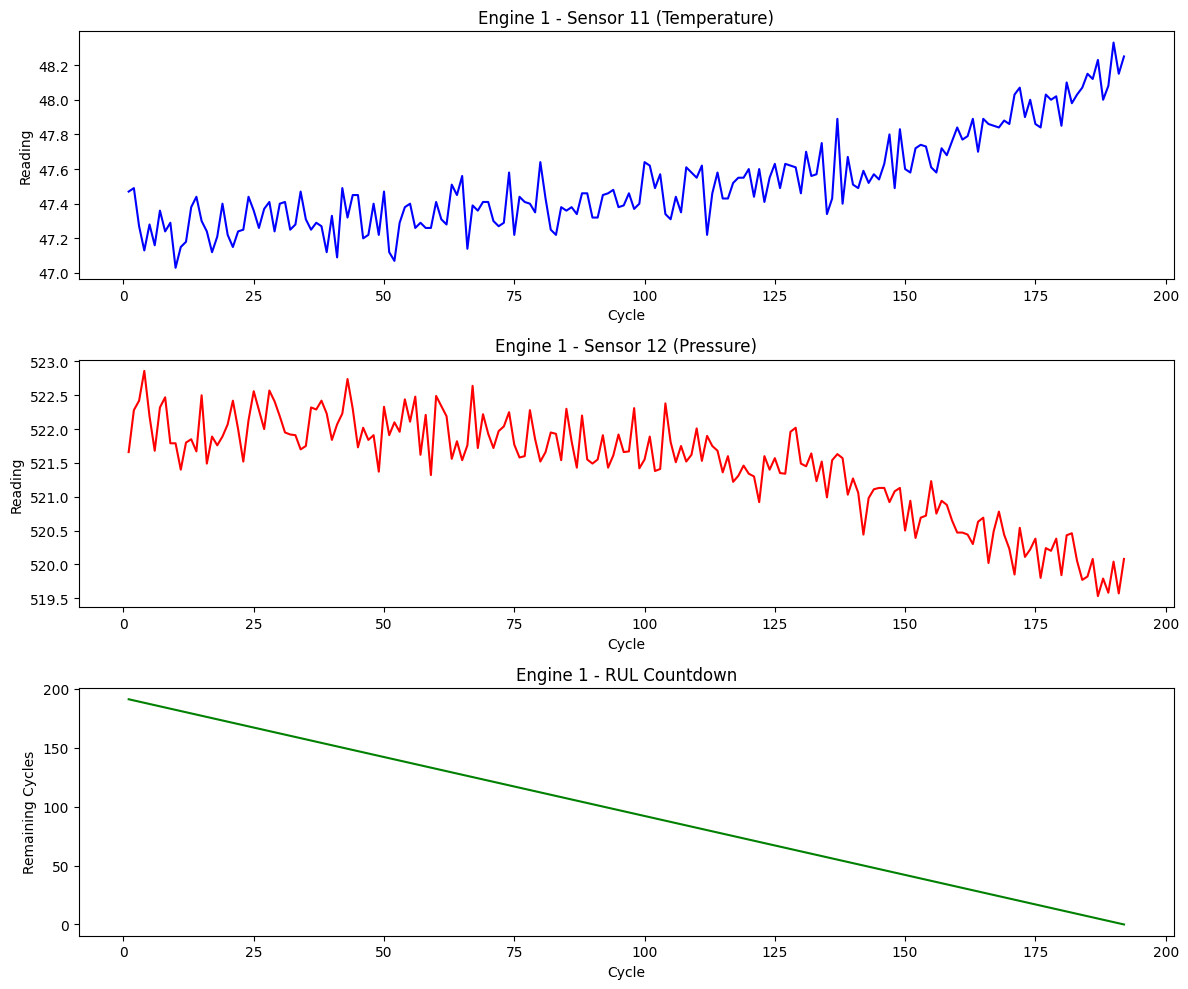

In [4]:
# Plot sensor readings for engine 1 over time
engine_1 = train[train['unit'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Sensor 11 - one of the most informative sensors
axes[0].plot(engine_1['cycle'], engine_1['s11'], color='blue')
axes[0].set_title('Engine 1 - Sensor 11 (Temperature)')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Reading')

# Sensor 12
axes[1].plot(engine_1['cycle'], engine_1['s12'], color='red')
axes[1].set_title('Engine 1 - Sensor 12 (Pressure)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Reading')

# RUL countdown
axes[2].plot(engine_1['cycle'], engine_1['RUL'], color='green')
axes[2].set_title('Engine 1 - RUL Countdown')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('Remaining Cycles')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

drop_cols = ['op3', 's1', 's5', 's6', 's10', 's16', 's18', 's19', 'max_cycle']
train_clean = train.drop(columns=drop_cols)

X = train_clean.drop(columns=['unit', 'RUL'])
y = train_clean['RUL']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape)
print("y shape:", y.shape)

X shape: (20631, 17)
y shape: (20631,)


In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
model = XGBRegressor(n_estimators=100, max_depth=6, 
                     learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE: {mae:.2f} cycles")
print(f"\nMeaning: On average our prediction is off by {mae:.0f} cycles")

RMSE: 35.82 cycles
MAE: 25.52 cycles

Meaning: On average our prediction is off by 26 cycles


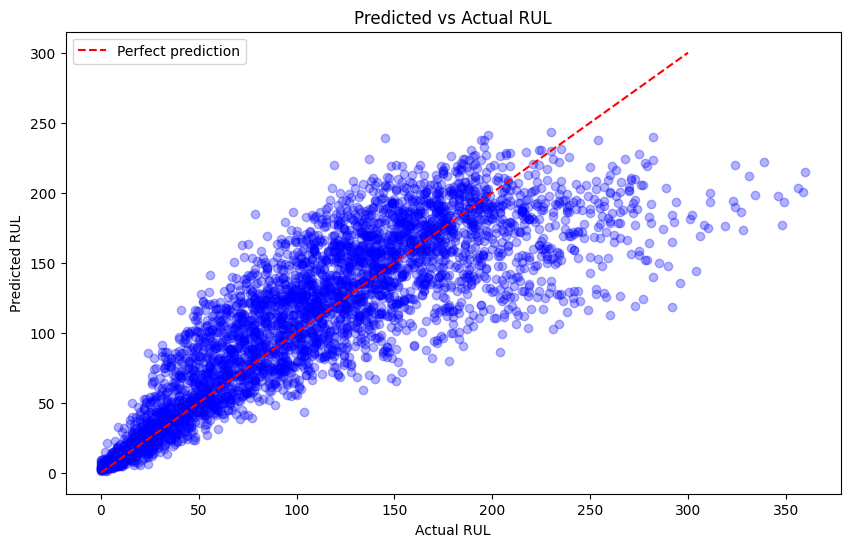

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([0, 300], [0, 300], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs Actual RUL')
plt.legend()
plt.show()

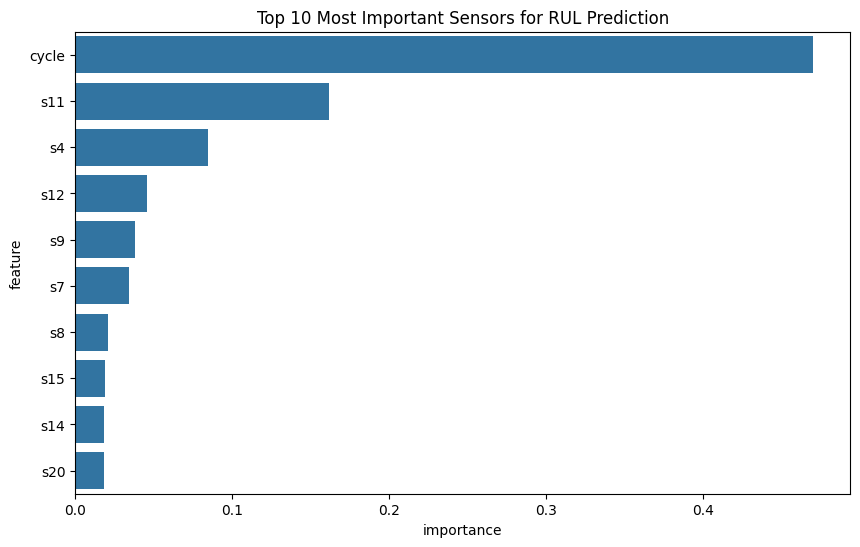

   feature  importance
0    cycle    0.470475
9      s11    0.161751
5       s4    0.084543
10     s12    0.045929
8       s9    0.038414
6       s7    0.034313
7       s8    0.021168
13     s15    0.019280
12     s14    0.018478
15     s20    0.018469


In [9]:
feature_names = train_clean.drop(columns=['unit', 'RUL']).columns
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Sensors for RUL Prediction')
plt.show()

print(feat_imp.head(10))